# Machine Learning Models Crash Course: Supervised Learning

In supervised learning, we give a model labeled examples: inputs, $X$, paired with known answers, $y$. The model learns a relationship from those examples, then we check how well it works on data it did not see during training.

This notebook uses the same housing dataset to ask different questions. That is intentional: changing the target changes the kind of problem, the model we choose, and the way we judge success.

We will cover:

1. **Linear regression**: predict a continuous value, such as house price.
2. **Logistic regression**: predict the probability of a binary category, such as whether a house is above a chosen price threshold.
3. **Decision trees**: learn a sequence of easy-to-follow rules for a classification task.
4. **Random forests**: combine many decision trees to produce a more stable classifier.

Along the way, pay attention to the shared workflow: define a question, create a valid target, separate training from testing data, choose a metric that fits the decision, and inspect the model's mistakes.


#### A Few Terms Used Below
- **Features ($X$)** are the input columns used to make a prediction; the **target ($y$)** is the known answer the model is trying to learn.
- **Regression** predicts a continuous number, such as price. **Classification** predicts a category or the probability of a category.
- A **train/test split** holds some data back so we can test the model on examples it did not see while learning.
- In linear regression, a **coefficient** describes the fitted relationship with a feature, an **intercept** is the prediction when that feature is zero, and a **residual** is the gap between an actual value and its prediction.
- A **probability threshold** turns a classification probability into a class prediction. The common 0.5 threshold is a choice, not a rule.
- A **confusion matrix** counts correct and incorrect classifications. **Precision**, **recall**, and **F1** help us understand the mistakes beyond overall accuracy.
- **Class imbalance** means one class is much rarer than the other. **Overfitting** means a model learns training-specific detail that does not generalize. **Data leakage** makes performance look unrealistically good by revealing information the model would not have at prediction time.
- In a decision tree, **Gini impurity** measures how mixed the classes are in a node. **Bagging** trains models on different bootstrap samples and combines them, as a random forest does.

---

In [4]:
import kagglehub
import os
import pandas as pd


import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier  # import the model for random forest classification
from sklearn.model_selection import train_test_split


from sklearn.metrics import classification_report, confusion_matrix

In [5]:
from data_loader import load_housing_data
df = load_housing_data()

----

## 1. Linear Regression Model

Linear regression helps us model the relationship between a dependent variable and one or more independent variables by fitting a straight line to the data. We can use that line to predict future values and see how strongly the predictors affect the outcome.

For simple linear regression, the standard formula is $Y = a + bX$:

- **Y**: the dependent variable, or the value we want to predict.
- **X**: the independent variable, or predictor.
- **b**: the slope, which shows how much $Y$ changes for every one-unit increase in $X$.
- **a**: the y-intercept, which shows the predicted value of $Y$ when $X$ is zero.

The linear model's Coefficient: 461.9748942727831, Intercept: 2387308.4823964317 provides insight into the relationship between area and price.
The coefficient indicates how much the price is expected to increase for each additional unit of area, in this case we see the value is 461.9748942727831, meaning for every additional unit of area, the price is expected to increase by 461.9748942727831 units. 
The intercept represents the expected price when the area is zero, in this case we see the value is 2387308.4823964317, meaning when the area is zero, the expected price is 2387308.4823964317 units.
So, the increase of the coefficient and the intercept mean that the price is expected to increase as the area increases, and the intercept indicates that there is a base price even when the area is zero.


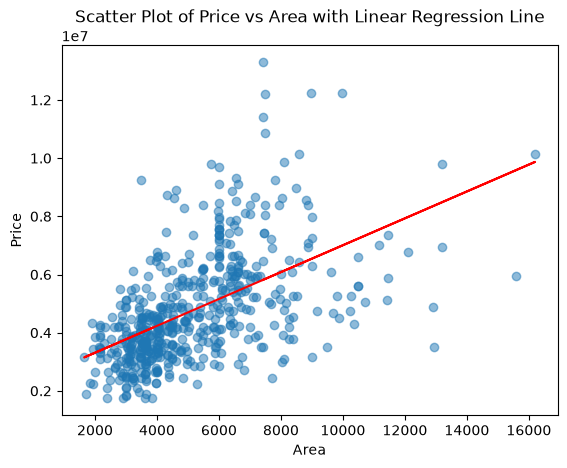

In [6]:
X = df[['area']]
y = df['price'] 

reg = LinearRegression()
reg.fit(X, y) 


#this fits the linear regression model to the data, learning the relationship between the area and price of houses. 
#The model will find the best-fitting line that minimizes the difference between the predicted prices and the actual prices in the dataset.
print(f"The linear model's Coefficient: {reg.coef_[0]}, Intercept: {reg.intercept_} provides insight into the relationship between area and price.")
print(f"The coefficient indicates how much the price is expected to increase for each additional unit of area, in this case we see the value is {reg.coef_[0]}, meaning for every additional unit of area, the price is expected to increase by {reg.coef_[0]} units. "
      f"\nThe intercept represents the expected price when the area is zero, in this case we see the value is {reg.intercept_}, meaning when the area is zero, the expected price is {reg.intercept_} units."
      f"\nSo, the increase of the coefficient and the intercept mean that the price is expected to increase as the area increases, and the intercept indicates that there is a base price even when the area is zero.")

plt.scatter(df['area'], df['price'], alpha=0.5)
plt.plot(df['area'], reg.predict(X), color='red')
plt.title('Scatter Plot of Price vs Area with Linear Regression Line')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()


### Graph Explanation

This graph shows the relationship between a house's area ($X$) and its price ($Y$), along with the fitted linear-regression line. The upward line suggests a **positive** relationship: as area increases, price tends to increase as well.

In [7]:
# Add a constant column so the model can estimate an intercept.
# This lets the fitted line have a baseline value rather than forcing it through (0, 0).
# In statsmodels, "exog" refers to the exogenous, or predictor, variables.
exog = sm.add_constant(X)

# Fit an Ordinary Least Squares (OLS) model. OLS finds the line that minimizes
# the sum of squared differences between observed and predicted prices.
model = sm.OLS(y, exog).fit()

# Review the estimated coefficients, statistical tests, and goodness-of-fit measures.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     218.9
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           7.39e-42
Time:                        15:52:15   Log-Likelihood:                -8551.2
No. Observations:                 545   AIC:                         1.711e+04
Df Residuals:                     543   BIC:                         1.712e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.387e+06   1.74e+05     13.681      0.0

### Summary Explanation

The OLS summary answers a different question from a prediction test. It describes the relationship estimated from this dataset and gives statistical evidence about the fitted coefficients. A few fields are especially useful:

- **Coefficient for `area`**: the estimated average change in price associated with one additional unit of area, holding the model's other inputs fixed. This simple model has only one input, so it is an association between area and price, not proof that area alone causes price to change.
- **p-value for `area`**: tests the null hypothesis that the fitted area coefficient is zero. A small p-value is evidence that the observed association is unlikely under that null hypothesis; it is not a measure of how accurate the predictions are.
- **$R^2$**: the fraction of variation in price explained by this fitted line. With area as the only feature, a modest $R^2$ is a reminder that location, condition, amenities, and many other factors also affect price.
- **F-statistic and Prob (F-statistic)**: test whether this model fits better than an intercept-only model. They describe evidence for the fitted relationship, not whether the result is important in a business sense.

The diagnostic fields are prompts for caution, not a pass-or-fail checklist. For example, non-normal residuals can affect some statistical inference, and a Durbin-Watson statistic is most useful when observations have a meaningful order, such as a time series. Housing rows are cross-sectional, so residual plots and held-out prediction errors are more useful next checks.

To evaluate this model as a predictor, create a train/test split before fitting it and report a held-out error such as RMSE alongside $R^2$. That separates "the line describes these observed houses" from "the line predicts new houses well."

---
## 2. Logistic Regression

Logistic regression predicts the probability of a binary outcome: a “yes” or “no” answer. It takes a linear equation and passes it through the sigmoid, or logistic, function. This transforms the result into a smooth S-shaped curve that stays between 0 and 1.

- **P**: the predicted probability.
- **a + bX**: the familiar linear equation: intercept plus slope times input.
- **e**: Euler's constant, approximately 2.718.

Before we can use logistic regression, we need a binary target column. In this example, we will label a home as a luxury house (`1`) or not (`0`) using a price threshold.

In [8]:
# This is an initial example of creating a binary luxury-house target.
# In the next cell, we use the median price instead so both classes are represented.
df['target_luxury_house'] = (df['price'] > 1000000).astype(int)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,target_luxury_house
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1


In [9]:
# Define a logistic-regression model that predicts luxury-house status from area.
logistic_reg_model = LogisticRegression()

# Use the median price as the threshold so the target has roughly balanced classes.
luxury_threshold = df['price'].median()
df['target_luxury_house'] = (df['price'] >= luxury_threshold).astype(int)

# Split the predictors and target into reproducible training and test sets.
# Stratification preserves the class proportions in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['target_luxury_house'],
    test_size=0.2,
    random_state=42,
    stratify=df['target_luxury_house']
)

# Logistic regression requires examples from both target classes during training.
if y_train.nunique() < 2:
    raise ValueError("The training data must contain both target classes.")

# Fit the model, then calculate the predicted probability of the positive class.
logistic_reg_model.fit(X_train, y_train)
y_prob = logistic_reg_model.predict_proba(X_test)[:, 1]

# Fit a statsmodels logit model on the same training data for statistical inference.
# The constant column lets the model estimate an intercept.
x_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, x_train_const)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.587214
         Iterations 6
                            Logit Regression Results                           
Dep. Variable:     target_luxury_house   No. Observations:                  436
Model:                           Logit   Df Residuals:                      434
Method:                            MLE   Df Model:                            1
Date:                 Thu, 03 Sep 2026   Pseudo R-squ.:                  0.1528
Time:                         15:52:15   Log-Likelihood:                -256.03
converged:                        True   LL-Null:                       -302.19
Covariance Type:             nonrobust   LLR p-value:                 7.310e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7650      0.350     -7.907      0.000      -3.450      -2.080
area           0.0006

### Summary Explanation

The logistic model estimates the probability that a house belongs to the positive class. Here, the positive class is defined using the median price, which gives roughly balanced classes for a teaching example. That does **not** make it a natural definition of "luxury"; a real project would choose the label with domain stakeholders and a decision in mind.

- The coefficient for `area` describes how area is associated with the **log-odds** of being above the chosen threshold. Its sign tells us the direction of the relationship; the raw number is less intuitive than a predicted-probability plot.
- The `P>|z|` value tests whether the fitted coefficient differs from zero. Logistic regression uses a z-statistic because it is fitted with maximum likelihood rather than ordinary least squares.
- Statsmodels reports McFadden's **pseudo $R^2$**. It compares the fitted model with an intercept-only model, but it is not on the same scale as linear-regression $R^2$ and should not be read as a percentage of variance explained.

The real prediction check comes next: examine predicted probabilities and the confusion matrix on the test set. The default threshold of 0.5 is a convention, not a law. Move it higher when false positives are costly; move it lower when missing positive cases is costly.

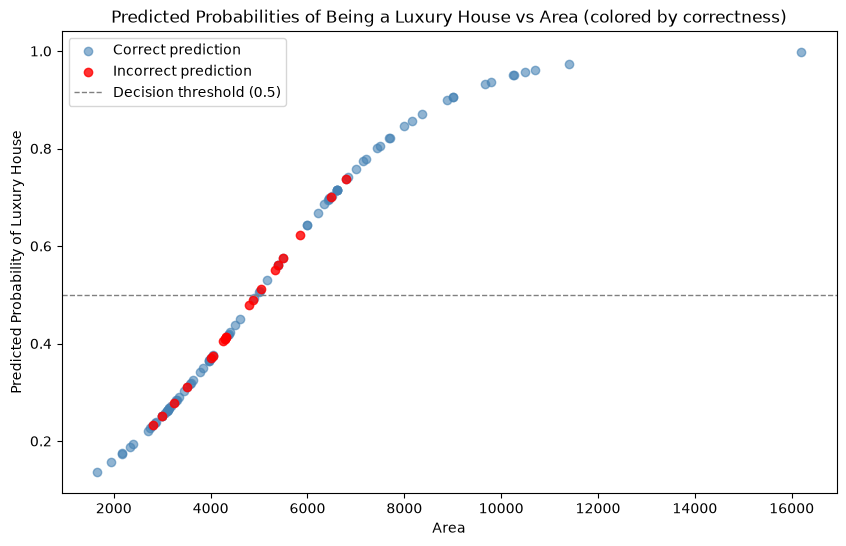

In [10]:
# show the predicted probabilities of being a luxury house for the test set on a graph
# Visualize correct vs incorrect predictions on the probability curve
y_pred = logistic_reg_model.predict(X_test) # predict the binary outcomes (0 or 1) for the test set (X_test) using the fitted logistic regression model.
correct = (y_test.values == y_pred)  # boolean array: True where prediction matched the true label

plt.figure(figsize=(10, 6))
plt.scatter(X_test.loc[correct], y_prob[correct], 
            color='steelblue', alpha=0.6, label='Correct prediction')
plt.scatter(X_test[~correct], y_prob[~correct], 
            color='red', alpha=0.8, label='Incorrect prediction')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.xlabel('Area')
plt.ylabel('Predicted Probability of Luxury House')
plt.title('Predicted Probabilities of Being a Luxury House vs Area (colored by correctness)')
plt.legend()
plt.show()

### Graph Explanation

- The call to `logistic_reg_model.fit(X_train, y_train)` lets the model learn a logistic curve that separates luxury and non-luxury houses from their area. You can think of this as a classification-focused counterpart to the earlier linear-regression graph.
- Each point represents a house in the test set. The x-axis shows its area, and the y-axis shows the model's predicted probability that it is a luxury house.
- The red points are the houses that `predict()` classified incorrectly. They cluster near the 0.5 decision threshold, which gives us visual evidence of the model's uncertainty near the cutoff.
- For every house, the model produces a probability from 0 to 1. Smaller houses tend toward a probability near 0, larger houses tend toward 1, and mid-sized houses often fall near 0.5, where the model is less certain.

Text(0, 0.5, 'True Labels')

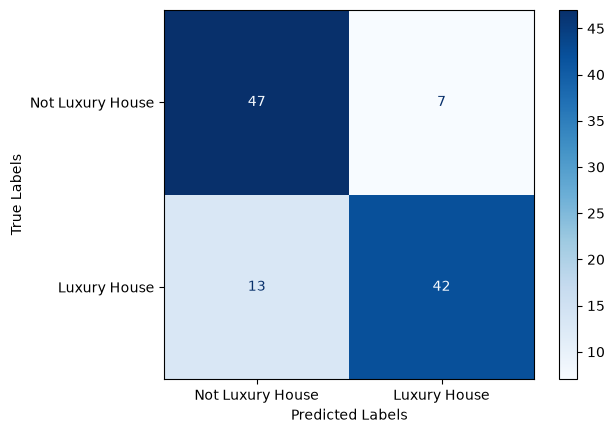

In [11]:

cm = confusion_matrix(y_test, y_pred) # compute the confusion matrix to evaluate the accuracy of the classification model by comparing the true labels (y_test) with the predicted labels (y_pred).
y_axis_labels = ['Not Luxury House', 'Luxury House'] # define the labels for the y-axis of the confusion matrix plot, corresponding to the two classes in the target variable (target_luxury_house).
x_axis_labels = ['Not Luxury House', 'Luxury House'] # define the labels for the x-axis of the confusion matrix plot, corresponding to the two classes in the target variable (target_luxury_house).
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=x_axis_labels) # create a ConfusionMatrixDisplay object to visualize the confusion matrix, using the computed confusion matrix (cm) and the class labels from the logistic regression model (logistic_reg_model.classes_).
disp.plot(cmap=plt.cm.Blues) # plot the confusion matrix using a blue color map for better visualization. The confusion matrix provides a summary of the model's performance, showing the number
disp.ax_.set_xlabel('Predicted Labels')
disp.ax_.set_ylabel('True Labels')


### Graph Explanation

- This confusion matrix summarizes the same predictions shown in the probability plot, but as binary 0/1 classifications rather than continuous probabilities. Each cell counts test-set houses by their true and predicted labels.
- The diagonal cells (47 and 42) are correct predictions: 47 houses were correctly identified as “Not Luxury,” and 42 were correctly identified as “Luxury.”
- The off-diagonal cells (7 and 13) are errors. Seven houses were not luxury but were predicted to be luxury (false positives), while 13 were luxury but were predicted to be not luxury (false negatives).
- These errors connect directly to the red points in the probability plot. Because their predicted probabilities were close to 0.5, a small shift in area could move them across the decision boundary and change the classification.
- The overall accuracy is $(47 + 42) / 109 \approx 82\%$. The confusion matrix turns a spectrum of prediction confidence into four simple counts, making model performance easier to inspect.

### Where Bayes' Theorem Fits

Bayes' theorem describes how to update a probability after observing evidence:

$$P(\text{Luxury} \mid \text{Area}) = \frac{P(\text{Area} \mid \text{Luxury}) \times P(\text{Luxury})}{P(\text{Area})}$$

In words: start with a **prior** belief about how common luxury houses are, then update it after seeing a house's area. A larger area may raise the probability, but it does not determine it by itself.

Logistic regression is not Bayes' theorem. Logistic regression directly learns a probability curve from labeled examples, while a Bayesian approach combines a prior with a model of how likely the evidence is under each class. Both produce probabilities, which is why they are often discussed together, but they make different modeling assumptions.

---
## 3. Decision Trees

A decision tree works like a flowchart. It asks a sequence of yes-or-no questions about features in the data, splitting the data at each step until it can make a prediction.

- **Root node**: the starting point, containing all training data.
- **Internal nodes**: points where the tree splits data using feature-based questions.
- **Leaf nodes**: endpoints that contain the final prediction or class label.

Trees can solve both regression and classification problems. They use the same splitting logic, but their leaf nodes return different results:

- A **classifier** predicts the majority class among the training examples that reach a leaf. For example: “Most houses here were luxury, so predict luxury.”
- A **regressor** predicts the average target value among the training examples that reach a leaf. For example: “Houses here average $650,000, so predict $650,000.”

Tree depth is not determined by the number of output categories. It depends on the number and type of informative features available for splitting.

For this first tree, we will ask: **How many rentable spaces does a house have?** Our target has three possible values: 0, 1, or 2 rentable spaces.

### Choosing Features

Why do we need a different question for this model?

- Basement and guestroom are binary features, so the tree has only a few meaningful splits to combine. That is enough to classify 0, 1, or 2 rentable spaces clearly.
- Area is a continuous feature, so a tree could keep splitting it many times. However, going deeper than necessary can make the model memorize noise instead of learning a useful pattern.

The more useful question is not “Will this make the tree deep enough?” Instead, ask: **Do we have enough distinct, informative features for the tree to combine?** One feature, such as area, gives us a simple tree. Two binary features give us a slightly richer tree. With many relevant features, a tree can model meaningful interactions, which is where it can become especially useful.

### Feature Engineering

To make the tree more meaningful, we will add a feature that asks: **How ready are these spaces for renting?** The `furnishingstatus` column has an order we can encode: furnished, semi-furnished, then unfurnished. For this lesson, we will assume that a furnished basement or guestroom is more ready to rent than an unfurnished one.

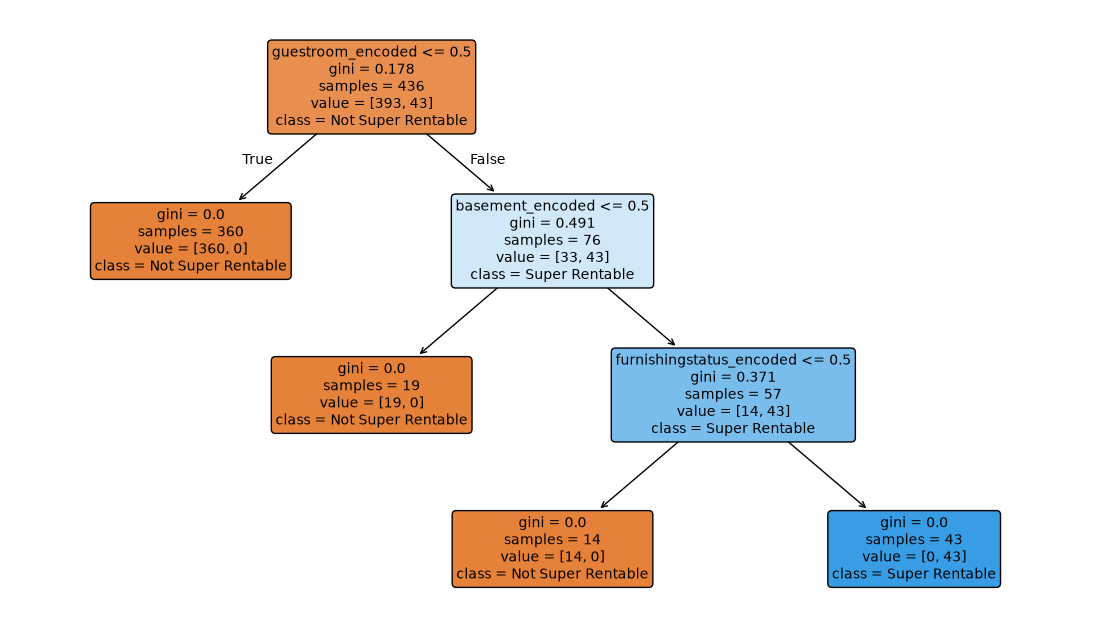

Accuracy: 1.0
[[98  0]
 [ 0 11]]


In [12]:
# Create the target: 0, 1, or 2 rentable spaces based on a basement and guestroom.
df['rentable_spaces'] = (
    (df['basement'] == 'yes').astype(int)
    + (df['guestroom'] == 'yes').astype(int)
)

# A house is super rentable when it has both spaces and is not unfurnished.
df['super_rentable'] = (
    (df['rentable_spaces'] == 2)
    & (df['furnishingstatus'] != 'unfurnished')
).astype(int)

# Convert categorical values to numeric features the model can use.
furnish_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishingstatus_encoded'] = df['furnishingstatus'].map(furnish_map)
df['basement_encoded'] = (df['basement'] == 'yes').astype(int)
df['guestroom_encoded'] = (df['guestroom'] == 'yes').astype(int)

features = ['basement_encoded', 'guestroom_encoded', 'furnishingstatus_encoded']
X = df[features]
y = df['super_rentable']
# Use y = df['rentable_spaces'] instead to predict the 0/1/2 version.

# Keep the class proportions consistent between the training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit a shallow tree so we can inspect the rules it learns.
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    feature_names=features,
    class_names=['Not Super Rentable', 'Super Rentable'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

y_pred = tree_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

### Graph Explanation

**Root node: `guestroom_encoded <= 0.5`**

- This asks whether `guestroom` is 0 (no) or 1 (yes). Scikit-learn writes this binary split as `<= 0.5`: 0 is true, and 1 is false.
- The root starts with 436 training samples: 393 “Not Super Rentable” and 43 “Super Rentable.”
- The tree selects `guestroom` first because it is the most informative single feature.

**Left branch: no guestroom**

- This branch is a pure leaf: all 360 samples are “Not Super Rentable” and its Gini impurity is 0.0.
- That matches our rule. A super-rentable house needs both a basement and a guestroom, so a house without a guestroom cannot qualify.

**Right branch: has a guestroom**

- The tree next asks whether the house has a basement. Houses without a basement form another pure “Not Super Rentable” leaf.
- For houses with both spaces, the final split checks `furnishingstatus_encoded`. Unfurnished homes are classified as “Not Super Rentable,” while semi-furnished and furnished homes are classified as “Super Rentable.”

### What Does This Tell Us?

Every leaf has a Gini impurity of 0.0, which means the tree separates the training examples perfectly. However, the tree is not discovering an unknown pattern: it is reconstructing the rule we used to create `super_rentable` from the same input features. This is a form of data leakage, so it does not tell us how well the model would generalize to a new, independent question.

To make the task more challenging, we will predict `super_rentable` using features that did not define it: area, price, and bedrooms.

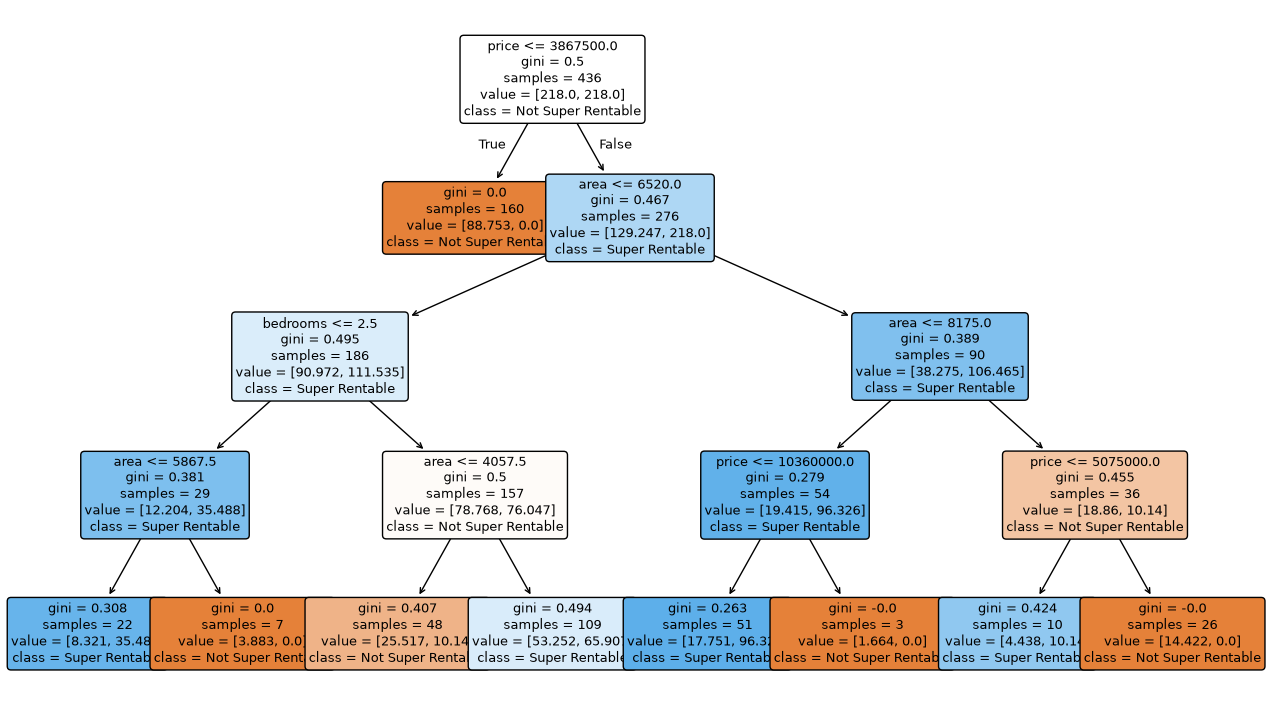

Accuracy: 0.6513761467889908
[[64 34]
 [ 4  7]]
                    precision    recall  f1-score   support

Not Super Rentable       0.94      0.65      0.77        98
    Super Rentable       0.17      0.64      0.27        11

          accuracy                           0.65       109
         macro avg       0.56      0.64      0.52       109
      weighted avg       0.86      0.65      0.72       109



In [13]:
# Use features that are independent of how we constructed super_rentable.
features = ['area', 'price', 'bedrooms']
X = df[features]
y = df['super_rentable']

# Create a reproducible, stratified training and test split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balance the minority class during training and limit depth to reduce overfitting.
tree_model2 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
tree_model2.fit(X_train, y_train)

plt.figure(figsize=(16, 9))
plot_tree(
    tree_model2,
    feature_names=features,
    class_names=['Not Super Rentable', 'Super Rentable'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

# Evaluate the model with class-level metrics as well as overall accuracy.
y_pred = tree_model2.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Not Super Rentable', 'Super Rentable']))

### Graph Explanation

- Unlike the earlier tree, most leaves here have Gini impurity above 0. This means the model cannot perfectly separate the classes using only area, price, and bedrooms. That is expected: unlike the earlier features, these predictors did not define `super_rentable`.
- Price appears at many levels of the tree. This suggests that, among these three features, price contains the most information about whether a house is super rentable. Price was not part of the target definition, but expensive homes may be more likely to include amenities such as a basement, guestroom, or furnishing.
- The class imbalance matters. There are far fewer “Super Rentable” examples, so a tree can obtain high accuracy simply by predicting the majority class most of the time.

### Looking Beyond Accuracy

Accuracy can be misleading for an imbalanced dataset. If 98 of 109 test houses are “Not Super Rentable,” a model that predicts that class every time would still be about 90% accurate while never identifying a super-rentable house.

Using `class_weight='balanced'` changes the cost of mistakes during training. The model pays more attention to the minority class, which can improve recall: it finds more real super-rentable houses. The tradeoff is that it may also produce more false positives, reducing precision and overall accuracy.

This is the **precision-recall tradeoff**. Which metric matters more depends on the real-world cost of each error:

- Prioritize **recall** when missing a genuinely super-rentable house is costly.
- Prioritize **precision** when incorrectly labeling a house as super rentable is costly.

Neither choice is universally better. We need to choose the metric that reflects the problem we are trying to solve.

### Next Steps

- Use `max_depth`, `min_samples_leaf`, and `min_samples_split` to help control overfitting.
- Use `feature_importances_` to measure how much each feature contributed to the tree.
- Use cross-validation to check whether results are stable across several train/test splits.
- Compare split criteria such as Gini impurity and entropy.

---
## 4. Random Forest

A random forest builds many decision trees and combines their predictions. A single tree can overfit the training data and may not generalize well to unseen examples. By averaging or voting across many trees, a forest reduces variance and can produce more stable predictions.

*many trees trained on randomized views of the same training data, then combined. The randomization encourages trees to make somewhat different mistakes; the vote makes any one tree’s odd mistake less influential.*

Random forests create variation in two ways:

1. **Bootstrap sampling (bagging)**: each tree trains on a random sample of the training rows, selected with replacement. A row can appear more than once in a sample, while other rows may not appear at all.
2. **Random feature selection**: at every split, each tree considers only a random subset of the available features. This prevents every tree from relying on the same dominant feature and helps the forest make less-correlated predictions.

Together, these choices let each tree learn from a different view of the data. When individual trees make different mistakes, combining their predictions can reduce the effect of those mistakes.

For our imbalanced `super_rentable` problem, we will ask: **Does a balanced random forest improve detection of the minority class while preserving reasonable precision and accuracy compared with a single balanced decision tree?**

Accuracy: 0.7155963302752294
[[72 26]
 [ 5  6]]
                    precision    recall  f1-score   support

Not Super Rentable       0.94      0.73      0.82        98
    Super Rentable       0.19      0.55      0.28        11

          accuracy                           0.72       109
         macro avg       0.56      0.64      0.55       109
      weighted avg       0.86      0.72      0.77       109



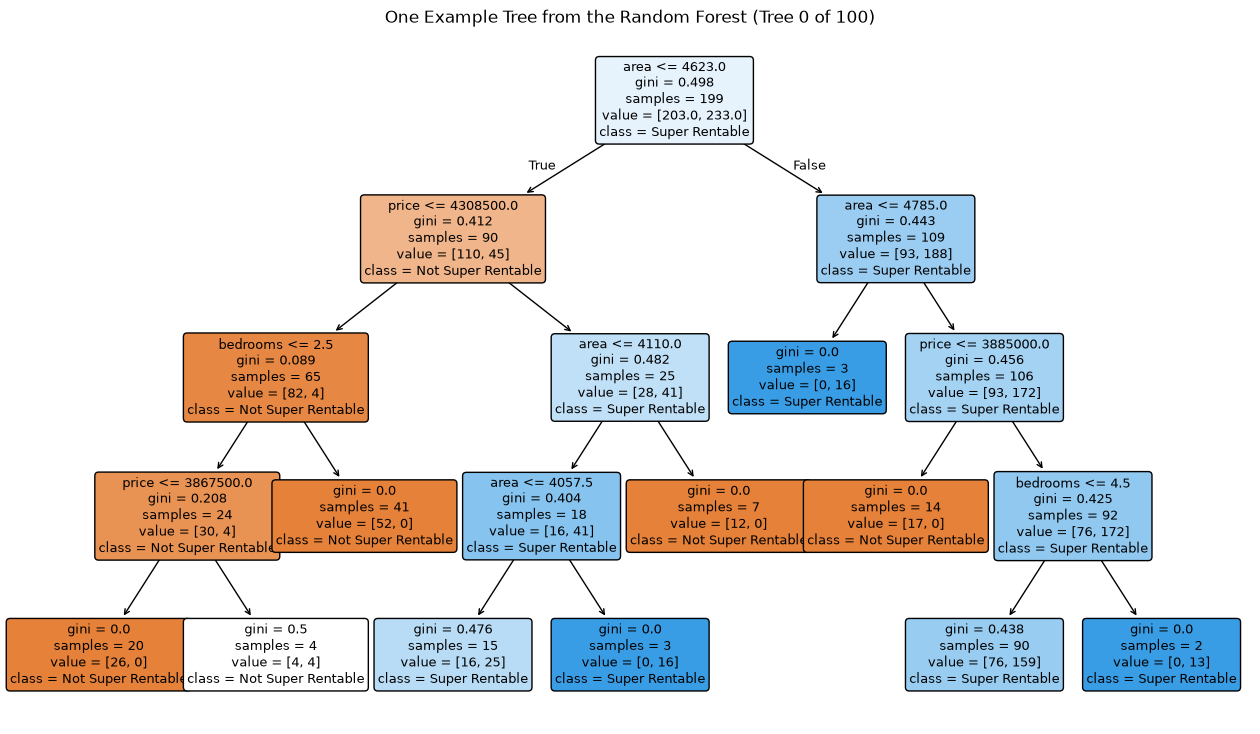

In [ ]:
# We reuse the same features and target from the single-tree experiment.
# how does this model compare to the single decision tree? 
# the way it works is that it builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. 
# Each tree is trained on a random subset of the data and features, which helps to capture different patterns in the data. 
# The final prediction is made by aggregating the predictions from all the trees, typically through majority voting for classification tasks.
# Does that mean that each node is just a single decision tree? No, each node is part of a decision tree, and the random forest consists of many such trees. Each tree makes its own predictions, and the final output is determined by combining the predictions from all the trees in the forest.
# as an example the not super rentable node is basically the aggregation of an entire not super rentable tree, and the super rentable node is the aggregation of an entire super rentable tree? Each node in a decision tree represents a decision based on a feature and a threshold, not an entire tree. The aggregation happens at the level of the final predictions from all the trees in the forest, not at individual nodes.

features = ['area', 'price', 'bedrooms']
X = df[features]
y = df['super_rentable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest.
    max_depth=4,            # Cap each tree's depth to match the single-tree comparison.
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", rf_model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Not Super Rentable', 'Super Rentable']))

# We visualize one tree to see an individual estimator inside the forest.
plt.figure(figsize=(16, 9))
plot_tree(
    rf_model.estimators_[0],
    feature_names=features,
    class_names=['Not Super Rentable', 'Super Rentable'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("One Example Tree from the Random Forest (Tree 0 of 100)")
plt.show()

### Graph Explanation: Comparing the Random Forest with a Single Decision Tree

- Accuracy improves from 0.651 to 0.716, and precision rises slightly from 0.17 to 0.19. The forest is a little less likely to label a house “Super Rentable” without enough evidence.
- Recall drops from 0.64 to 0.55. The forest finds 6 of 11 actual super-rentable houses, compared with 7 of 11 for the single balanced tree.
- The F1 score changes only slightly, from 0.27 to 0.28. In this experiment, the random forest does not meaningfully solve the class-imbalance problem; it simply moves to a slightly different point on the precision-recall tradeoff.

### Did the Random Forest Win?

Not decisively, and that is a useful result. A random forest can reduce overfitting when each tree has enough signal to learn from. Here, the full training set contains only 43 positive examples, and each bootstrap sample may contain even fewer. Averaging many trees that each have limited evidence about the minority class cannot create more information than the data contains.

The important lesson is that the data, not the model choice, is the primary limitation in this example. Moving from a decision tree to a random forest or gradient boosting will not automatically fix a shortage of positive examples. Resampling techniques such as oversampling or SMOTE can be more helpful because they address the imbalance directly.

---
## Review of Supervised Learning

Supervised learning starts with examples that include both the inputs, $X$, and a known answer, $y$. The model learns a relationship from the training examples, then we test whether that relationship is useful on data it did not see while learning. The important question is not only "Can this model fit the data?" but "Will it make reliable decisions on new data?"

### Regression: predicting a number

- **Linear regression** predicts a continuous value, such as house price from area. It fits the line that makes its prediction errors as small as possible overall.
- A coefficient describes an association in the fitted data. It does not prove that changing the feature causes the target to change, and a statistically significant coefficient can still have weak predictive value.
- Use held-out data and regression metrics such as mean squared error, root mean squared error, and $R^2$ when the goal is prediction. The OLS summary is useful for inference, but it is not a substitute for testing predictions on unseen data.

### Classification: predicting a category or probability

- **Logistic regression** predicts the probability of a class. A 0.5 cutoff turns that probability into a yes-or-no prediction, but the best threshold depends on the cost of false positives and false negatives.
- **Decision trees** make predictions through a sequence of simple feature-based rules. They are easy to inspect but can memorize training data if they grow too deep.
- **Random forests** combine many varied decision trees. Averaging their predictions usually reduces the instability of one tree, but it cannot compensate for missing features or too few positive examples.

### Evaluation and Data Quality

- Keep training and test data separate. Training performance shows how well a model learned its examples; test performance estimates how it may behave on new ones.
- Watch for **data leakage**. If a feature directly reveals how a target was created, the model can appear excellent without solving a meaningful prediction problem.
- Accuracy can hide a weak classifier when one class is rare. Inspect the confusion matrix, precision, recall, and F1 score, then choose the metric that matches the decision you are making.
- A more complex model is not automatically better. Start with a baseline, compare results on the same split or cross-validation folds, and explain what practical improvement the added complexity earns.

### Ideas to Carry Forward

- Match the model to the question: a number calls for regression; a category calls for classification.
- Match the metric and decision threshold to the real cost of mistakes.
- Treat model results as evidence, not proof. Look at errors, assumptions, feature quality, and what additional data could make the decision better.

---